# PCA: Principal Component Analysis

Principal Component Analysis or PCA points is a dimension reduction technique that gives the direction that explains the most variability in a dataset. It is mostly used in exploratory data analysis and visualization. 

Suppose we have a data matrix with many correlated variables. Using naive regression techniques in such a setting can lead to problems such as multicolinearity and curse of dimensionality. PCA constructs small number of ordered uncorrelated axes, which are called principal components, such that the first captures the most variance in the dataset. each principal component follows the previous one in amount of variablity explained. Projecting the data onto first few principal components reveals pattern or structure which are hidden in the original dataset or matrix. 

In this documentation, we will depomstrate implementation of PCA using `BigRiverEssence.pca` on the well known `R` dataset, `iris`. We will then visualize the results using a scree plot, a principal-component scatter plot, and a biplot. 

## The Dataset

 The `iris` dataset is contains $4$ flower features (sepal length, sepal width, petal length, petal width) for $150$ plants. The plants are classified as one of the three species: Setosa, Versicolor, and Virginica. The `iris` dataset can be considered as a matrix with $n=150$ rows and $p=4$ variables, one for each feature.

 In the function `pca`, observations needs to be in rows and the variables should be in column. Hence, we first get the `iris` dataset from `R` and construct a $150 \times 4$ matrix.
 

In [ ]:
using BigRiverEssence
const BRE = BigRiverEssence

using RDatasets, DataFrames, Plots, Statistics, LinearAlgebra
gr()

iris = dataset("datasets", "iris")
features = [:SepalLength, :SepalWidth, :PetalLength, :PetalWidth]
X = Matrix{Float64}(iris[:, features])
species = iris.Species           
size(X) 

  Activating project at `~/Desktop/UTHSC internship/Julia/BigRiverSchneider.jl`


(150, 4)

## The method summary

- We will center each variable (and can optionally scales it to unit variance).
- We will then finds the the principal components which are the eigenvectors of the covariance matrix obtained as the right singular vectors of the centered data.
- We will then project the observations onto the directions of the principal components to obtain scores. We can then report
   how much of the total variance are explained by each of the principal components.


## Fitting the model

Measurements of the different columns can be at different scales, hence it is always advisible to standardize each
variables to unit variance. We fit `pca` on the data matrix `X` while considering standardized columns of `X`. We can get the proportion of total variance explained by each of the four principal components using `propOFvar`. 

In [ ]:
m = BRE.pca(X; standardize = true)
m.propOFvar

4-element Vector{Float64}:
 0.7296244541330079
 0.22850761786701357
 0.03668921889282435
 0.005178709107153818

We can see that the first component explains around $73\%$ of the total varinace of `X` and the first two components together explains around  $96\%$. Hence We can say that the first two components should suffice in summarizing the
iris data. 

## Scree plot

A scree plot is just a bar plot where each bar shows the variance captured by each individual component. The "elbow" in the scree plot is a good indicator that can help decide how many components are worth keeping. We can use `propOFvar` to get the scree plot.

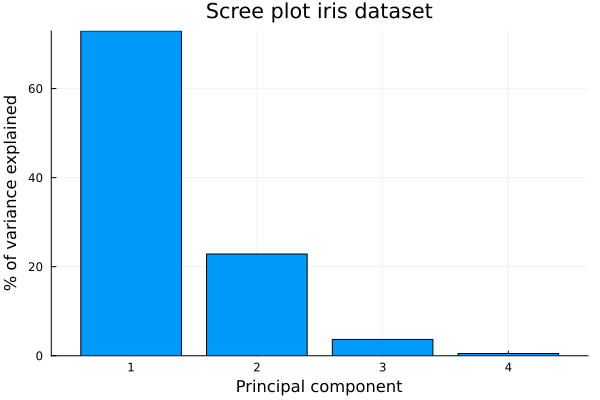

In [33]:
pve = m.propOFvar
bar(pve .* 100;
    xlabel = "Principal component", ylabel = "% of variance explained",
    title = "Scree plot iris dataset", legend = false, xticks = 1:length(pve))

We can see that the first bar dominates. A good reason for this can be that the iris measurements are highly correlated, hence a single axis or principal component can captures most of the variation.

## Principal-component scatterplot

Since it is obvious from the scree plot above, thate the first two principal component dominates. We can now project `X` onto  the first two principal components using the function `pca_transform`. This will yeild us a two-dimensional score. We make a scatter plot of the two score colouring the observations by their species. 

Projecting the flowers onto the first two principal components gives each one a
two-dimensional *score*. Coloring by species reveals what PCA found.


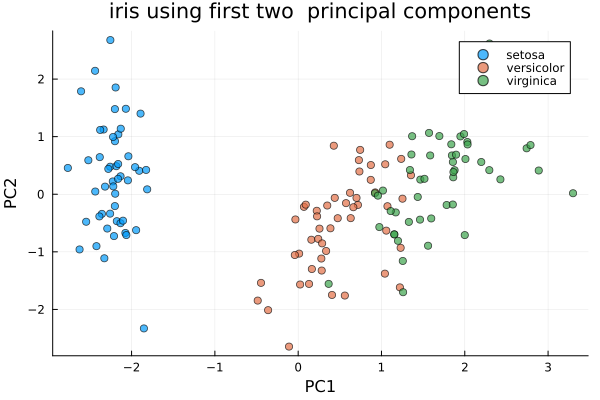

In [ ]:

scores = BRE.pca_transform(m, X)          # 150×4 scores
scatter(scores[:, 1], scores[:, 2]; group = species,
    xlabel = "PC1", ylabel = "PC2",
    title = "iris using first two  principal components",
    legend = :topright, markeralpha = 0.7)

We can see in the above plot, the first two components were able to completely separate setosa and were able to
split versicolor* from virginica with only mild overlap. 

## Biplot


After fitting `pca`, we can get loadings using `loadings`. Loadings are the weights which says how much each original variable contributes to a particular component.

A biplot iscatterplot of the scores from the first two principal components overlayed with the loadings (as seen as arrows). Now we remake the scatterplot with arrows denoting the loadings. 


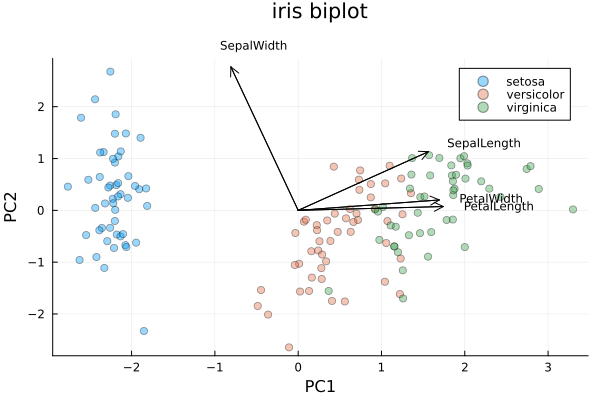

In [35]:
L = m.loadings
arrowscale = 3.0

plt = scatter(scores[:, 1], scores[:, 2]; group = species,
    xlabel = "PC1", ylabel = "PC2", title = "iris biplot",
    legend = :topright, markeralpha = 0.4,
    top_margin = 8Plots.mm)       
for j in 1:length(features)
    quiver!([0], [0], quiver = ([L[j,1]*arrowscale], [L[j,2]*arrowscale]); color = :black)
    annotate!(L[j,1]*arrowscale*1.15, L[j,2]*arrowscale*1.15,
              text(string(features[j]), 8, :black, :left))
end
plt

We can see in the biplot that the petal-length and petal-width arrows are pointing  strongly along PC1. This shows that the petal
size is the dominant source of variation and is the dimension along which the species
separate. Since the sepal measurements points in other direction than PC1, they contribute comparatively less.

## Inverse transformation

We just saw that`pca_transform` projects the original data matrix down to component scores. The other function `pca_invtransform`
maps the scores back into the original four measurements. If we keep all the components, we should be able to recover the data matrix exactly. 

In [ ]:
X_recon = BRE.pca_invtransform(m, scores)
maximum(abs.(X .- X_recon))   

1.7763568394002505e-15

We see from the above output, keeping all the components, we are able to reconstruct `X` almost exactly. Now if we keep only the first two components, this gives us a low-rank approximation which we can see from the output below, it is close but not
exact as the difference between the two matrices are larger than when we used all components for the reconstruction. 

In [ ]:
m2 = BRE.pca(X; k = 2, standardize = true)
X_approx = BRE.pca_invtransform(m2, BRE.pca_transform(m2, X))
maximum(abs.(X .- X_approx))      # small, but nonzero

0.6490170097395849

## Summary

Here we demonstrated the use of PCA using the `pca` function from the Julia package `BigRiverEssence.jl`. PCA can also be applied to any similar dataset where the goal is dimension reduction.

